In [106]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import shapely.vectorized as sv

from multiprocessing import Pool
from joblib import Parallel, delayed

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale

In [107]:
npix = 2
yy_s, yy_e = 2002, 2023
NEIBHR = 2*npix+1

In [108]:
# product, time_reso = 'IMERG', '3h'
# product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'MSWEP', '3h'
product, time_reso = 'ERA5', '3h'
# product, time_reso = 'GSMaP', '3h'
# product, time_reso = 'CHIRPS', '1dy'

In [109]:
# PADOVA
# lon_min, lon_max, lat_min, lat_max, area = 11, 12.5, 45, 46, 'PADOVA'
# VENETO
lon_min, lon_max, lat_min, lat_max, area = 10.5, 13.5, 44.5, 47, 'VENETO'
# ITALY
# lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [110]:
if area == 'PADOVA':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Padova.geojson'))
elif area == 'VENETO':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Veneto.geojson'))
elif area == 'ITALY':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))
else:
    sys.exit("Area not recognized. Please choose 'VENETO' or 'ITALY'.")

GEOMETRY_union = GEOMETRY.unary_union

/tmp/ipykernel_22293/726573604.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  GEOMETRY_union = GEOMETRY.unary_union


In [111]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [112]:
DEM =  gpd.read_file(os.path.join(veneto_dir,'DEM','Italy_dem_1000.geojson'))

In [113]:
if product == 'IMERG':
    filename = 'IMERG_Italy_3h_2001_01_01_2023_12_31.nc'

elif product == 'CMORPH':
    filename = 'CMORPH_Italy_3hr_1998_01_01_2023_12_31.nc'

elif product == 'MSWEP':
    filename = 'MSWEP_Italy_3h_1980_01_01_2023_12_31.nc'

elif product == 'ERA5':
    filename = 'ERA5_Italy_3h_2000_01_01_2023_12_31.nc'

elif product == 'GSMaP':
    filename = 'GSMaP_Italy_3h_2002_01_01_2024_12_31.nc'

elif product == 'CHIRPS':
    filename = 'CHIRPS_Italy_1dy_1981_01_01_2024_06_30.nc'

else:
    sys.exit('Product not found')

In [114]:
print(f'Product: {product}')
dir_input = os.path.join(dir_base,product,time_reso,filename)
DATA = xr.open_dataset(dir_input)
DATA = DATA.sel(time=DATA.time.dt.year.isin(np.arange(yy_s,yy_e+1)))
DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)

lats = DATA['lat'].data
lons = DATA['lon'].data

lon2d, lat2d = np.meshgrid(lons, lats)
mask_study = sv.contains(GEOMETRY_union, lon2d, lat2d)

indices_lat, indices_lon = np.where(mask_study)

Product: ERA5


In [115]:
if product == 'IMERG':
    origin = [10, 3]
    target = [0, 24]

elif product == 'CMORPH':
    origin = [25, 3]
    target = [0, 24]

elif product == 'MSWEP':
    origin = [10, 3]
    target = [0, 24]

elif product == 'ERA5':
    origin = [25, 3]
    target = [0, 24]

elif product == 'GSMaP':
    origin = [10, 3]
    target = [0, 24]

elif product == 'CHRIPS':
    origin = [5, 24]
    target = [0, 24]

print(f'Product: {product}')
print(f'xscale : {origin[0]} km to {target[0]} km')
print(f'tscale : {origin[1]} hr to {target[1]} hr')

Product: ERA5
xscale : 25 km to 0 km
tscale : 3 hr to 24 hr


In [116]:
PRE_data_T = DATA.transpose('lon', 'lat', 'time')
time_vector_dt = pd.to_datetime(PRE_data_T['PRE']['time'].values)
DATA_3h = xr.DataArray(PRE_data_T['PRE'],  
                        coords={
                            'lon':PRE_data_T['lon'].values, 
                            'lat':PRE_data_T['lat'].values, 
                            'time':time_vector_dt},
                        dims=('lon', 'lat', 'time'))

In [117]:
def compute_for_point(args):
    DATA_3h, la, lo = args
    lat_c = lats[la]
    lon_c = lons[lo]
    box_3h = DOWN_raw.create_box_v2(DATA_3h, lat_c, lon_c, npix)
    pwets, xscales, tscales = DOWN_raw.compute_pwet_xr(box_3h, 1, cube1size=npix, dt=3, tmax=96)  
    beta_ = ART_downscale.compute_beta(pwets, origin, target, xscales, tscales)
    return la, lo, beta_

tasks = (
    (DATA_3h, la, lo)
    for la, lo in zip(indices_lat, indices_lon)
)

with Pool(processes=25) as pool:
    results = list(pool.imap(compute_for_point, tasks, chunksize=1))

BETA = np.ones((len(lats), len(lons)))*np.nan
for la, lo, beta_ in results:
    BETA[la, lo] = beta_

In [118]:
BETA_xr = xr.Dataset(data_vars={
                    "BETA": (("lat","lon"), BETA),
                    },
    coords={'lat': lats, 'lon': lons},
    attrs=dict(description=f"Beta for '{product}' in the '{area}' area bounded by longitudes {lon_min} to {lon_max} and box size '{NEIBHR}x{NEIBHR}'."))

BETA_xr.BETA.attrs["units"] = "dimensionless"
BETA_xr.BETA.attrs["long_name"] = "Itermittency function between two generic scales"
BETA_xr.BETA.attrs["origname"] = "Beta"

DOWN_out = os.path.join('..','output',f'{area}_Beta_{product}_{time_reso}_{yy_s}_{yy_e}_npix_{npix}.nc')
print(f'Export Data to {DOWN_out}')
# BETA_xr.to_netcdf(DOWN_out)

Export Data to ../output/VENETO_Beta_ERA5_3h_2002_2023_npix_2.nc


In [119]:
data_dir = os.path.join(dir_base,'2_MEV','uncorrected','OLD',f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA = xr.open_dataset(data_dir)
lon2d_all, lat2d_all = np.meshgrid(DATA.lon, DATA.lat)

mask_italy = sv.contains(GEOMETRY_union, lon2d_all, lat2d_all)
BETA_old = DATA.BETA.where(mask_italy).values

# del DATA

In [120]:
np.nanmin(BETA), np.nanmax(BETA)

(0.269512402792757, 0.3718102257024413)

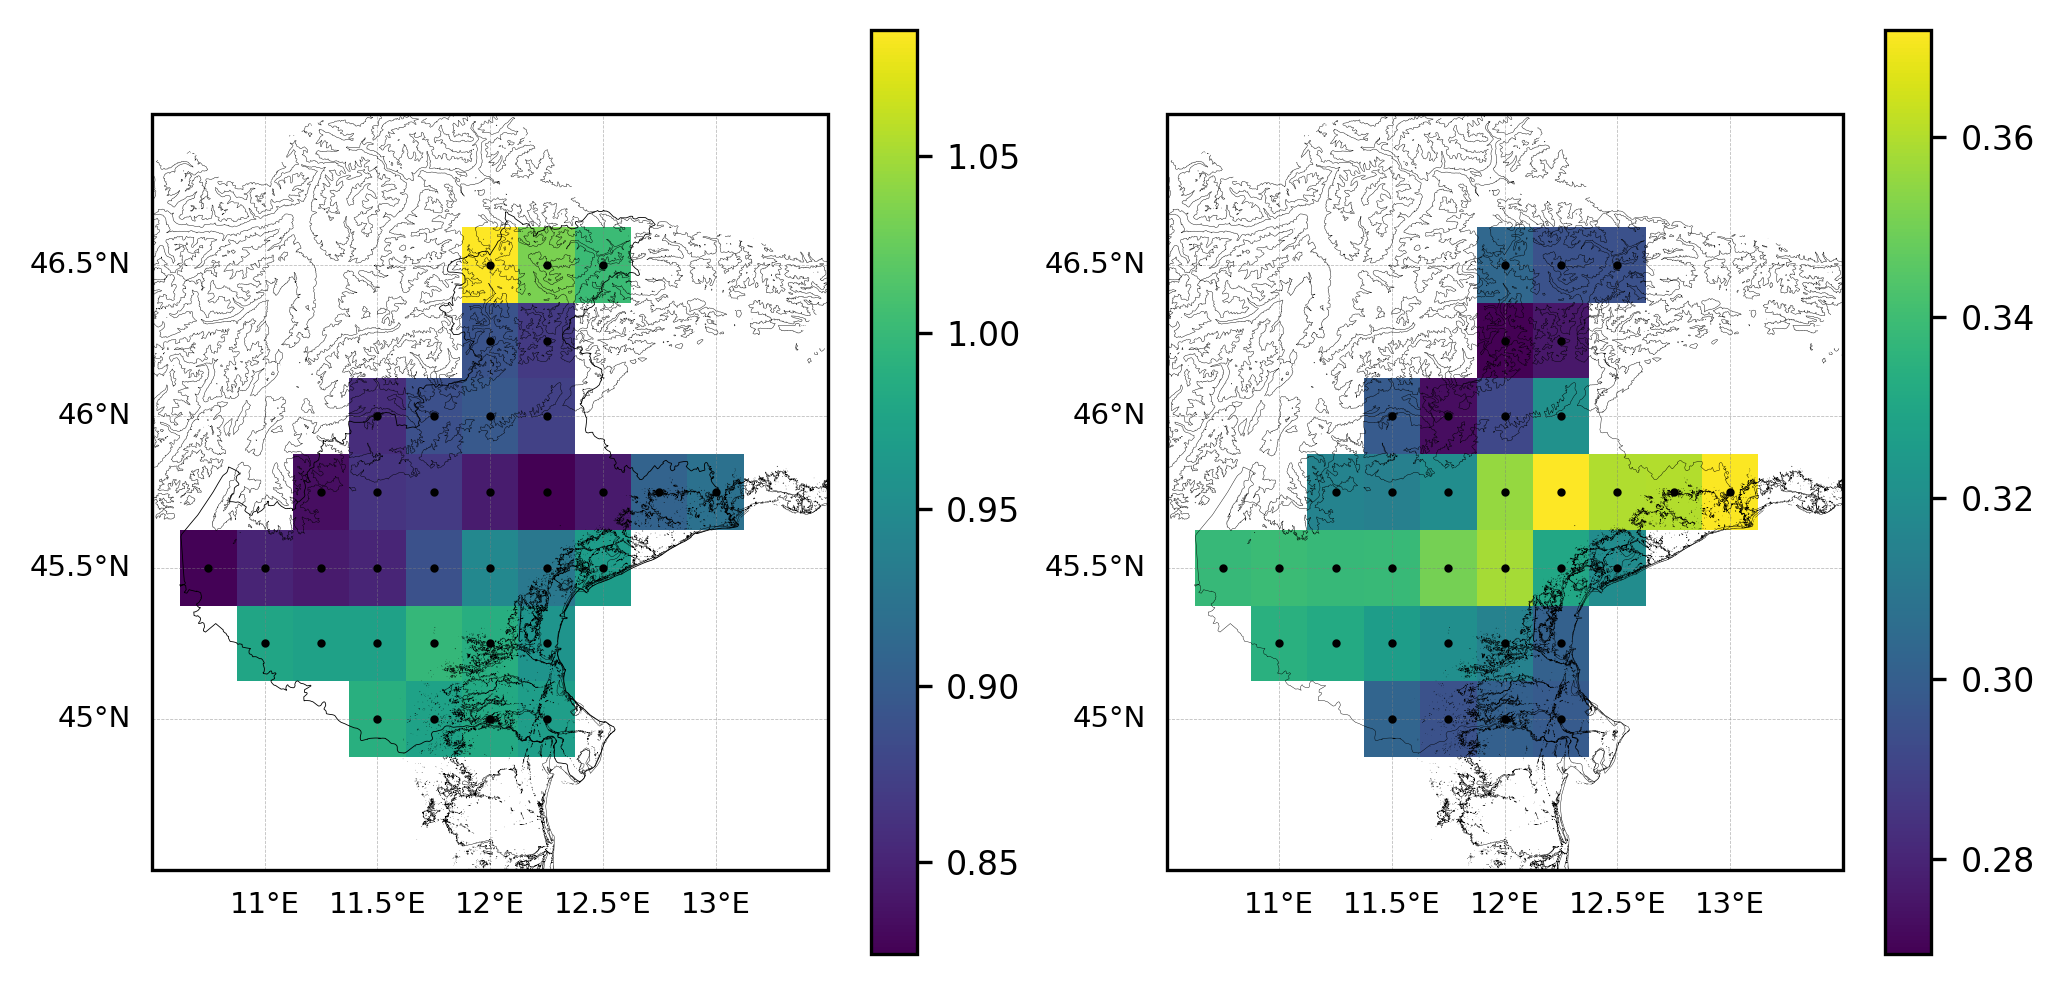

In [121]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(8,4),dpi=300)
gs = gridspec.GridSpec(1,2)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.2, ax=ax1, zorder=10)
DEM.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d_all, lat2d_all, BETA_old)
cbar = plt.colorbar(a1)
cbar.ax.tick_params(labelsize=8)

ax1.scatter(lons[indices_lon], lats[indices_lat], s=1, c='k', zorder=20)

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
DEM.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA_xr.BETA.values)
cbar = plt.colorbar(a1)
cbar.ax.tick_params(labelsize=8)

ax1.scatter(lons[indices_lon], lats[indices_lat], s=1, c='k', zorder=20)

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}